# Notebook 4-1 -- Composing Networks 

The purpose of this notebook is to understand whaat happens when we feed one neural network into another. It works through an example similar to 4.1 and varies both networks. 

In [6]:
using Plots

In [7]:
# Define the Rectified Linear Unit (ReLU) function 
function ReLU(preactivation)
    activation = max.(0.0, preactivation)
    return activation 
end 

ReLU (generic function with 1 method)

In [8]:
# Define a shallow neural network with one input, and three hidden units 

function Shallow_1_1_3(x, ActivationFn, ϕ₀, ϕ₁, ϕ₂, ϕ₃, θ₁₀, θ₁₁, θ₂₀, θ₂₁, θ₃₀,  θ₃₁)
    Pre₁ = θ₁₀ .+ θ₁₁ .* x 
    Pre₂ = θ₂₀ .+ θ₂₁ .* x 
    Pre₃ = θ₃₀ .+ θ₃₁ .* x 

    # pass through the ReLU function to compute the activation as in figure 3.3 d-f 
    Act₁ = ActivationFn(Pre₁)
    Act₂ = ActivationFn(Pre₂)
    Act₃ = ActivationFn(Pre₃)

    WAct₁ = ϕ₁ .* Act₁ 
    WAct₂ = ϕ₂ .* Act₂ 
    WAct₃ = ϕ₃ .* Act₃ 

    y = ϕ₀ .+ WAct₁ .+ WAct₂ .+ WAct₃ 
    return y, Pre₁, Pre₂, Pre₃, Act₁, Act₂, Act₃, WAct₁, WAct₂, WAct₃
end

Shallow_1_1_3 (generic function with 1 method)

In [9]:
# Plot two shallow neural networks and the composition of the two. 
function PlotNeuralTwoComposition(xIn, Net1Out, Net2Out, Net12Out = nothing)
    # plot the two networks seperately 
    p₁ = plot(xIn, Net1Out, color=:red, linestyle=:solid, legend=false, xlabel="Net 1 input", ylabel="Net 1 Output", xlims=(-1,1), ylims=(-1,1), aspect_ratio=1.0)
    
    p₂ = plot(xIn, Net2Out, color=:blue, linestyle=:solid, legend=false, xlabel="Net 2 input", ylabel="Net 2 Output", xlims=(-1,1), ylims=(-1,1), aspect_ratio=1.0)

    fig = plot(p₁, p₂, layout=(1,2), size=(850, 850))
    display(fig)

    if Net12Out !== nothing 
        # plot their composition 
        fig₂ = plot(xIn, Net12Out, color=:green, linestyle=:solid, legend=false, xlabel="Net 1 input", ylabel="Net 2 Output", xlims=(-1,1), ylims=(-1,1), aspect_ratio=1.0)
        display(fig₂)
    end
end

PlotNeuralTwoComposition (generic function with 2 methods)

Let's define two networks. We'll put the prefixes $n_1\_$ and $n_2\_$ before all the variables to make it clear which. We'll just consider the inputs and outputs over the range $[-1,1]$

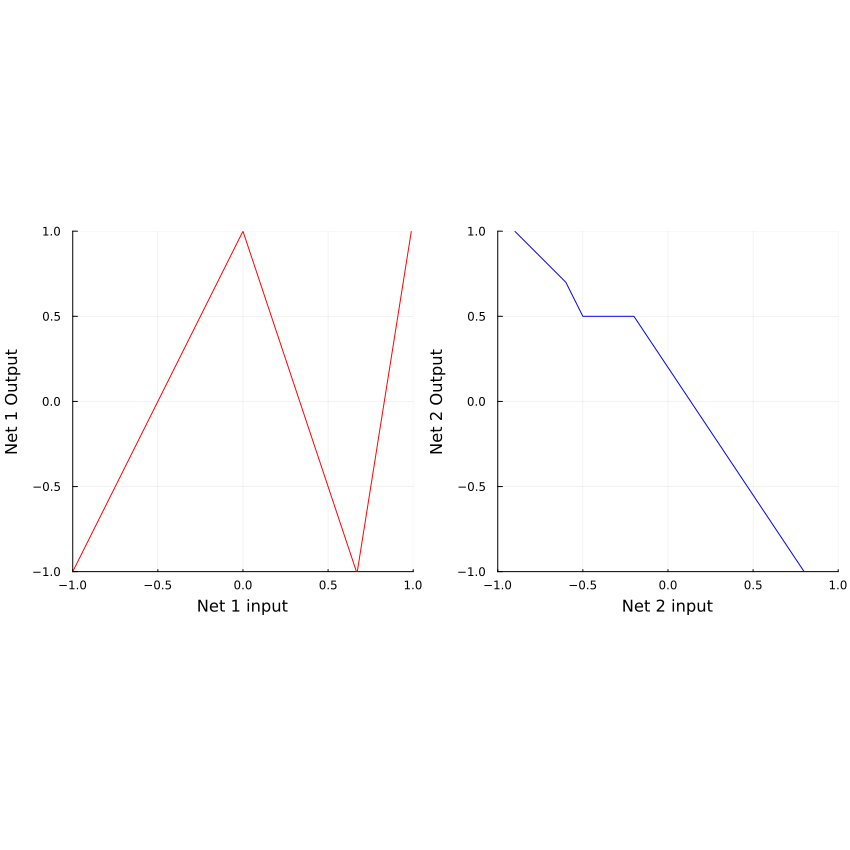

2000-element Vector{Float64}:
 -1.0
 -0.998
 -0.996
 -0.994
 -0.992
 -0.99
 -0.988
 -0.986
 -0.984
 -0.982
 -0.98
 -0.978
 -0.976
  ⋮
  0.9933999999999998
  0.9996999999999998
  1.0060000000000002
  1.0122999999999998
  1.0185999999999997
  1.0248999999999997
  1.0311999999999997
  1.0375
  1.0437999999999996
  1.0500999999999996
  1.0564
  1.0627

In [ ]:
# Now lets define some parameters and run the first neural network. 
n₁_θ₁₀ = 0.0; n₁_θ₁₁ = -1.0 
n₁_θ₂₀ = 0.0; n₁_θ₂₁ = 1.0 
n₁_θ₃₀ = -0.67; n₁_θ₃₁ = 1.0 
n₁_ϕ₀ = 1.0; n₁_ϕ₁ = -2.0; n₁_ϕ₂ = -3.0; n₁_ϕ₃ = 9.3 

# Now lets define some parameters and run the second neural network 
n₂_θ₁₀ = -0.6; n₂_θ₁₁ = -1.0
n₂_θ₂₀ = 0.2; n₂_θ₂₁ = 1.0 
n₂_θ₃₀ = -0.5; n₂_θ₃₁ = -1.0
n₂_ϕ₀ = 0.5; n₂_ϕ₁ = -1.0; n₂_ϕ₂ = -1.5; n₂_ϕ₃ = 2.0 

# display the two outputs 
x = -1.0:0.001:1-0.001

# We run the first and second neural network for each of these input values 
Net1Out, = Shallow_1_1_3(x, ReLU, n₁_ϕ₀, n₁_ϕ₁, n₁_ϕ₂, n₁_ϕ₃, n₁_θ₁₀, n₁_θ₁₁, n₁_θ₂₀, n₁_θ₂₁, n₁_θ₃₀, n₁_θ₃₁) 
Net2Out, = Shallow_1_1_3(x, ReLU, n₂_ϕ₀, n₂_ϕ₁, n₂_ϕ₂, n₂_ϕ₃, n₂_θ₁₀, n₂_θ₁₁, n₂_θ₂₀, n₂_θ₂₁, n₂_θ₃₀, n₂_θ₃₁) 

# plot both graphs 
PlotNeuralTwoComposition(x, Net1Out, Net2Out)


## TODO
 
Take a piece of paper and draw what you think will happen when we feed the output of the first network into the second one.  Draw the relationship between the input of the first network and the output of the second one.
     

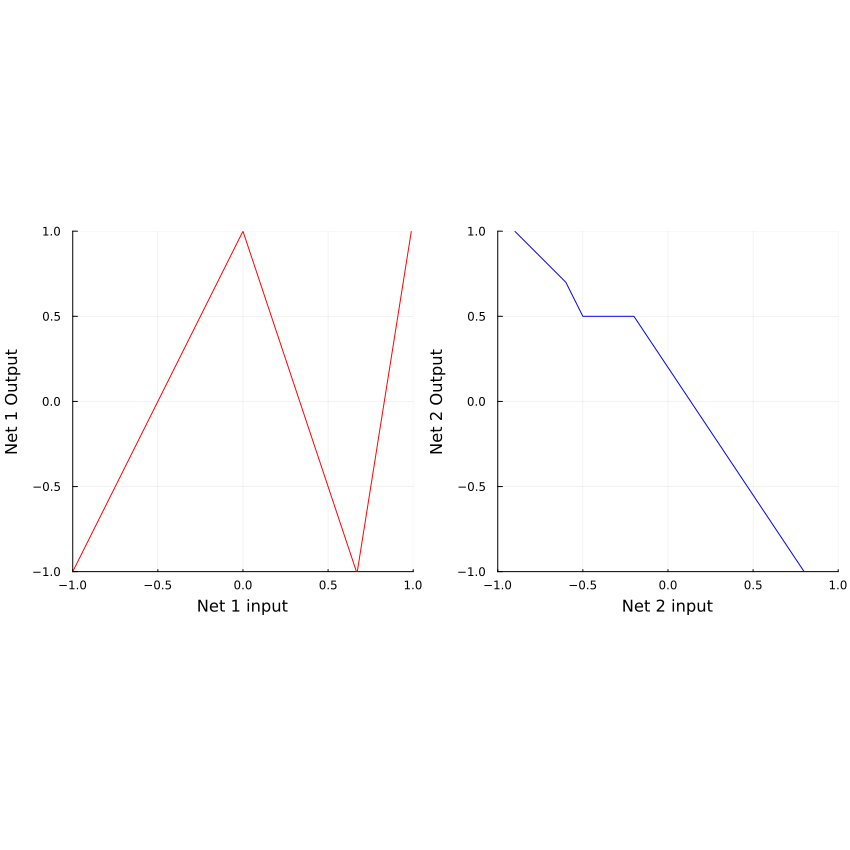

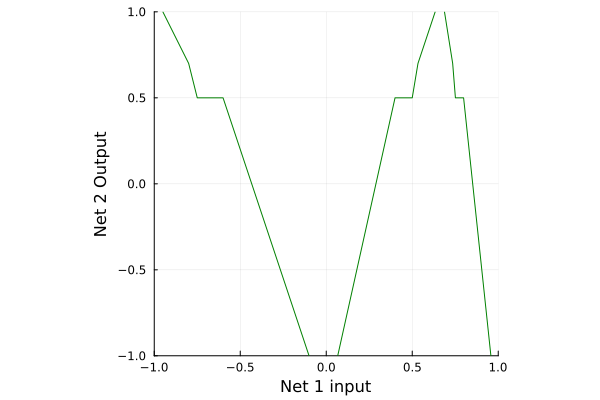

In [17]:
# Now let's see if your predictions were right 

# Feed the output of first network into second network 
Net12Out, = Shallow_1_1_3(Net1Out, ReLU, n₂_ϕ₀, n₂_ϕ₁, n₂_ϕ₂, n₂_ϕ₃, n₂_θ₁₀, n₂_θ₁₁, n₂_θ₂₀, n₂_θ₂₁, n₂_θ₃₀, n₂_θ₃₁) 

# plot all the graphs 
PlotNeuralTwoComposition(x, Net1Out, Net2Out, Net12Out)